In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from google.colab import drive

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, recall_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import xgboost as xgb

warnings.filterwarnings('ignore')
print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [3]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/PA 3 KEL 10-20260406T061058Z-3-001/PA 3 KEL 10/ML/diabetes_dataset.csv')
print("Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
df.head()

Mounted at /content/drive
Dataset berhasil dimuat!
Jumlah baris: 100000
Jumlah kolom: 16


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


eksplorasi data (EDA)

In [4]:
df.info()
print("\n")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDistribusi label:")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [6]:
print(df.isnull().sum())

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64


<Axes: ylabel='bmi'>

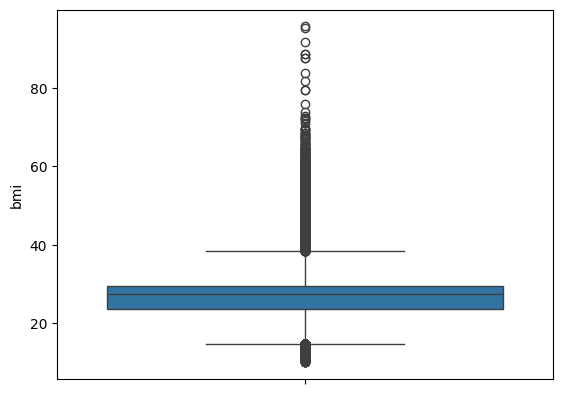

In [7]:
sns.boxplot(df['bmi'])

In [8]:
print(df['diabetes'].value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [9]:
print(df['smoking_history'].unique())
print(df[df['age'] < 10])

['never' 'not current' 'current' 'No Info' 'ever' 'former']
       year  gender   age location  race:AfricanAmerican  race:Asian  \
12     2015  Female  3.00  Alabama                     1           0   
16     2015  Female  2.00  Alabama                     0           1   
38     2015    Male  3.00  Alabama                     0           0   
40     2016    Male  8.00  Alabama                     0           1   
46     2015    Male  5.00  Alabama                     0           0   
...     ...     ...   ...      ...                   ...         ...   
99943  2016    Male  3.00  Wyoming                     0           1   
99944  2016  Female  2.00  Wyoming                     0           0   
99947  2016  Female  6.00  Wyoming                     1           0   
99983  2016    Male  5.00  Wyoming                     0           0   
99991  2016    Male  1.48  Wyoming                     0           0   

       race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disea

# Preprocessing: Noise, Outlier, dan Data Imbalance

Handle Noise mengisi NaN dengan modus:

In [10]:
df['smoking_history'] = df['smoking_history'].replace(
    'No Info', 
    df[df['smoking_history'] != 'No Info']['smoking_history'].mode()[0]
)


In [11]:
print(df['smoking_history'].head())

0    never
1    never
2    never
3    never
4    never
Name: smoking_history, dtype: object


In [13]:
print(df['smoking_history'].value_counts())

smoking_history
never          70911
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


Handle Outlier (menggunakan IQR pada kolom numerik)

In [12]:
def remove_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

for col in ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']:
    df = remove_outlier_iqr(df, col)

In [15]:
print("-" * 50 + f"\nTotal baris akhir setelah handling outlier: {len(df)}")

--------------------------------------------------
Total baris akhir setelah handling outlier: 90387


Handle Data Imbalance

# Feature Engineering, Encoding, Scaling, dan Dimensionality Reduction

Feature Engineering (contoh: membuat fitur baru dari clinical_notes jika ada)

In [13]:
if 'clinical_notes' in df.columns:
    df['notes_length'] = df['clinical_notes'].astype(str).apply(len)

Encoding (Label Encoding untuk kolom kategorikal, OneHot untuk yang sedikit unik)

In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'clinical_notes' in categorical_cols:
    categorical_cols.remove('clinical_notes') 
for col in categorical_cols:
    if df[col].nunique() <= 5:
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    else:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))


Scaling/Normalisasi (StandardScaler untuk numerik)

In [15]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'diabetes' in numeric_cols:
    numeric_cols.remove('diabetes')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])



Dimensionality Reduction (opsional, contoh dengan PCA)

In [16]:
do_pca = True 
if do_pca:
    pca = PCA(n_components=0.95, random_state=42)  # Simpan 95% variansi
    features = df.drop(['diabetes'], axis=1)
    features_pca = pca.fit_transform(features)
    df_pca = pd.DataFrame(features_pca, columns=[f'PC{i+1}' for i in range(features_pca.shape[1])])
    df_pca['diabetes'] = df['diabetes'].values
    print('Shape setelah PCA:', df_pca.shape)
else:
    df_pca = df.copy()

df_pca.head()

Shape setelah PCA: (90387, 13)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,diabetes
0,-0.652048,-0.692111,-0.360743,1.982971,-0.682002,-2.034151,-0.995610,-0.028434,0.392901,-0.050585,-0.044409,-0.305931,0
1,-1.402784,-0.785256,2.130622,-0.593679,-0.159983,0.564573,-1.069039,0.178682,1.511050,-2.548362,0.242454,0.477484,0
2,-1.184937,-0.614219,-0.187574,2.011738,-0.637348,0.585043,0.103691,-0.932273,0.355826,-2.960173,0.015044,-0.445235,0
3,-0.220483,-0.367616,-1.169554,-1.307700,-1.207442,0.691890,-0.784165,-1.531466,0.068234,-2.927654,-0.276888,-0.136787,0
4,-0.226830,2.202218,0.344618,0.167925,-0.123888,0.033960,-0.368083,0.165532,2.427810,-1.557826,-0.110564,0.776306,0


In [17]:
# Implementasi Random Forest untuk klasifikasi diabetes

# Gunakan df_pca jika sudah ada, jika tidak gunakan df
if 'df_pca' in globals():
    data = df_pca
else:
    data = df

X = data.drop('diabetes', axis=1)
y = data['diabetes']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))
print('Akurasi:', accuracy_score(y_test, y_pred_rf))

Confusion Matrix:
[[17130    49]
 [  527   372]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17179
           1       0.88      0.41      0.56       899

    accuracy                           0.97     18078
   macro avg       0.93      0.71      0.77     18078
weighted avg       0.97      0.97      0.96     18078

Akurasi: 0.968138068370395


In [18]:
# 1. Oversampling dengan SMOTE (rasio minoritas 1:1)
# Pastikan X dan y sudah terbentuk dari data hasil preprocessing dan feature engineering
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 2. Split data hasil SMOTE
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

# 3. RandomForest dengan class_weight='balanced'
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 4. Evaluasi
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))
print('Akurasi:', accuracy_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

# 5. (Opsional) Tuning threshold prediksi untuk maksimalkan recall kelas 1
y_proba = rf.predict_proba(X_test)[:,1]
best_recall = 0
best_thresh = 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_proba >= thresh).astype(int)
    recall_1 = recall_score(y_test, y_pred_thresh, pos_label=1)
    if recall_1 > best_recall:
        best_recall = recall_1
        best_thresh = thresh
print(f'Best threshold for recall kelas 1: {best_thresh:.2f} (recall={best_recall:.2f})')
# Catatan: Jalankan cell ini SETELAH X dan y terbentuk dari data hasil preprocessing, encoding, scaling, dsb.

Confusion Matrix:
[[16098  1081]
 [  217 16961]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     17179
           1       0.94      0.99      0.96     17178

    accuracy                           0.96     34357
   macro avg       0.96      0.96      0.96     34357
weighted avg       0.96      0.96      0.96     34357

Akurasi: 0.96222021713188
ROC AUC: 0.9956319171985339
Best threshold for recall kelas 1: 0.10 (recall=1.00)


### 1. Feature Selection (Random Forest Feature Importance)

In [19]:
# Feature Selection dengan Feature Importance dari Random Forest
importances = rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print('Feature Importance:')
print(feat_imp)

# Pilih fitur teratas (misal: 10 fitur terpenting)
top_n = 10
selected_features = feat_imp.head(top_n).index.tolist()
X_selected = X[selected_features]

Feature Importance:
PC1     0.286711
PC7     0.258279
PC11    0.097908
PC9     0.053218
PC8     0.052224
PC2     0.042926
PC3     0.040308
PC12    0.038900
PC4     0.035596
PC5     0.031492
PC10    0.031454
PC6     0.030985
dtype: float64


### 2A. Model Sebelum Tuning (Baseline Performance)

In [24]:
# Evaluasi Random Forest baseline (sebelum tuning)

print("="*60)
print("BASELINE MODEL (Random Forest default)")
print("="*60)

# Subset X_selected untuk train dan test set
X_selected_train = X_train[selected_features]
X_selected_test = X_test[selected_features]

# Train baseline model dengan default parameters pada selected features
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=1)
rf_baseline.fit(X_selected_train, y_train)
y_pred_baseline = rf_baseline.predict(X_selected_test)

# Baseline performance
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_cv = cross_val_score(rf_baseline, X_selected_train, y_train, cv=3, scoring='accuracy', n_jobs=1)

print(f"Test Accuracy (Baseline): {baseline_accuracy:.4f}")
print(f"CV Accuracy (Baseline): {baseline_cv.mean():.4f} (+/- {baseline_cv.std():.4f})")
print(f"\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_baseline))
print()

BASELINE MODEL (Random Forest default)
Test Accuracy (Baseline): 0.9581
CV Accuracy (Baseline): 0.9491 (+/- 0.0015)

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     17179
           1       0.94      0.98      0.96     17178

    accuracy                           0.96     34357
   macro avg       0.96      0.96      0.96     34357
weighted avg       0.96      0.96      0.96     34357




### 2B. Hyperparameter Tuning (Metode: GridSearchCV)

In [25]:
# Definisikan param_grid agar tidak error
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Inisialisasi model dengan penanganan data imbalanced
rf_grid = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=rf_grid, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

print("Fitting GridSearchCV... (Mencari kombinasi terbaik untuk F1-Score)\n")
grid_search.fit(X_selected_train, y_train)

print("\n" + "="*60)
print("Best Parameters Found:")
print("="*60)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score (F1): {grid_search.best_score_:.4f}\n")

Fitting GridSearchCV... (Mencari kombinasi terbaik untuk F1-Score)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

### 2C. Model Setelah Tuning (Tuned Performance) & Comparison

In [ ]:
# Evaluasi model setelah tuning dan bandingkan dengan baseline
print("="*60)
print("TUNED MODEL PERFORMANCE")
print("="*60)

# Get best model dari GridSearchCV
best_rf = grid_search.best_estimator_

# Prediksi dengan tuned model pada test set
y_pred_tuned = best_rf.predict(X_selected_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

# Cross validation score untuk tuned model
tuned_cv = cross_val_score(best_rf, X_selected_train, y_train, cv=3, scoring='accuracy')

print(f"Test Accuracy (Tuned): {tuned_accuracy:.4f}")
print(f"CV Accuracy (Tuned): {tuned_cv.mean():.4f} (+/- {tuned_cv.std():.4f})")
print(f"\nConfusion Matrix (Tuned):")
print(confusion_matrix(y_test, y_pred_tuned))
print(f"\nClassification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned))

print("\n" + "="*60)
print("PERBANDINGAN: BASELINE vs TUNED MODEL")
print("="*60)
improvement = ((tuned_accuracy - baseline_accuracy) / baseline_accuracy) * 100
print(f"Baseline Accuracy:  {baseline_accuracy:.4f}")
print(f"Tuned Accuracy:     {tuned_accuracy:.4f}")
print(f"Improvement:        {improvement:+.2f}%")
print(f"\nBaseline CV Score:  {baseline_cv.mean():.4f}")
print(f"Tuned CV Score:     {tuned_cv.mean():.4f}")
print(f"CV Improvement:     {((tuned_cv.mean() - baseline_cv.mean())/baseline_cv.mean()*100):+.2f}%")
print("="*60)

TUNED MODEL PERFORMANCE
Test Accuracy (Tuned): 0.9587
CV Accuracy (Tuned): 0.9494 (+/- 0.0014)

Confusion Matrix (Tuned):
[[16006  1173]
 [  246 16932]]

Classification Report (Tuned):
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     17179
           1       0.94      0.99      0.96     17178

    accuracy                           0.96     34357
   macro avg       0.96      0.96      0.96     34357
weighted avg       0.96      0.96      0.96     34357


PERBANDINGAN: BASELINE vs TUNED MODEL
Baseline Accuracy:  0.9581
Tuned Accuracy:     0.9587
Improvement:        +0.06%

Baseline CV Score:  0.9491
Tuned CV Score:     0.9494
CV Improvement:     +0.03%


## Hyperparameter Tuning (Final & Fixed)
Bagian ini mencakup:
1. Model sebelum tuning
2. Metode tuning (GridSearchCV)
3. Model setelah tuning

In [ ]:
# -- 0. Persiapan Mencegah Error --
# Pastikan fitur sudah diseleksi agar tidak muncul NameError
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

# -- 1. MODEL SEBELUM TUNING (Baseline) --
print("="*60)
print("1. MODEL SEBELUM TUNING (BASELINE)")
print("="*60)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_final, y_train)

y_pred_baseline = rf_baseline.predict(X_test_final)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Akurasi Baseline: {baseline_accuracy:.4f}\n")

# -- 2. METODE TUNING (GridSearchCV) --
print("="*60)
print("2. METODE TUNING (Menggunakan GridSearchCV)")
print("="*60)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Inisiasi model untuk tuning
rf_grid = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(
    estimator=rf_grid, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

print("Memulai GridSearchCV... (mohon tunggu sebentar)\n")
grid_search.fit(X_train_final, y_train)
print(f"Parameter Terbaik: {grid_search.best_params_}\n")

# -- 3. MODEL SETELAH TUNING --
print("="*60)
print("3. MODEL SETELAH TUNING (TUNED PERFORMANCE)")
print("="*60)
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_final)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Akurasi Setelah Tuning: {tuned_accuracy:.4f}")
print("\nClassification Report (Setelah Tuning):")
print(classification_report(y_test, y_pred_tuned))

# Ringkasan Peningkatan
improvement = ((tuned_accuracy - baseline_accuracy) / baseline_accuracy) * 100
print(f"\nRingkasan: Ada perubahan akurasi sebesar {improvement:+.2f}% setelah tuning.")


1. MODEL SEBELUM TUNING (BASELINE)
Akurasi Baseline: 0.9581

2. METODE TUNING (Menggunakan GridSearchCV)
Memulai GridSearchCV... (mohon tunggu sebentar)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


## Analisis Error, Interpretasi, dan Simpan Model

## Analisis Error, Interpretasi, dan Simpan Model
Tahapan lanjutan setelah training dan tuning:
1. Analisis error (misclassifications) dan visualisasi confusion matrix.
2. Interpretasi feature importance lebih detail.
3. Simpan model terbaik untuk prediksi ke depan.

Jumlah data yang salah klasifikasi: 1419
Contoh data yang salah klasifikasi:


,y_true,y_pred
0,0,1
1,1,0
2,0,1
3,0,1
4,0,1


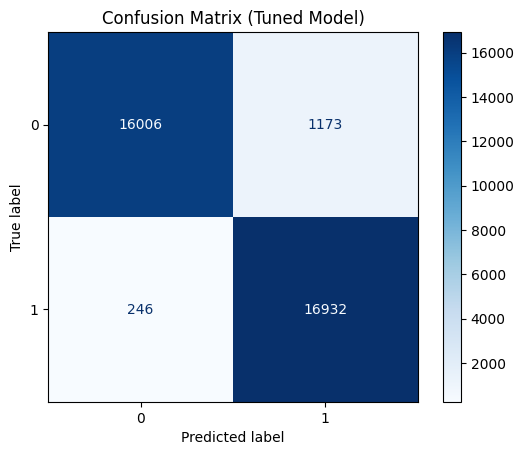

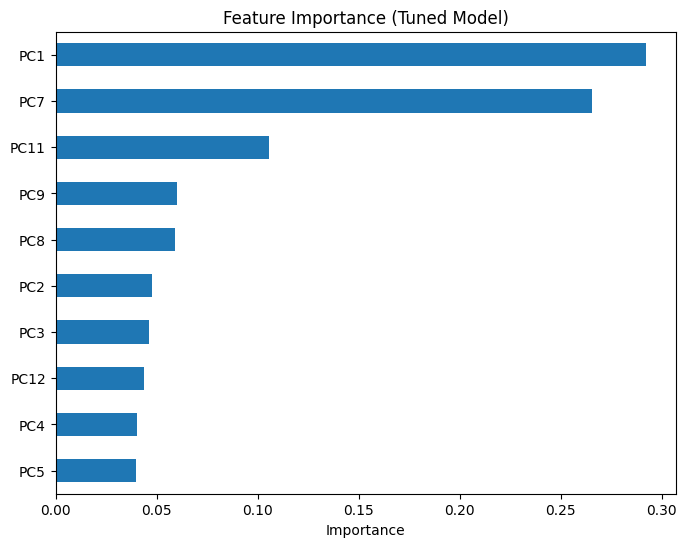

Model terbaik berhasil disimpan sebagai random_forest_diabetes_best.pkl


In [25]:
# 1. Analisis Error: Lihat prediksi yang salah (misclassifications)
 
# Asumsi: y_test dan y_pred_tuned sudah ada dari cell sebelumnya
misclassified_idx = np.where(y_test != y_pred_tuned)[0]
print(f'Jumlah data yang salah klasifikasi: {len(misclassified_idx)}')
print('Contoh data yang salah klasifikasi:')
display(pd.DataFrame({'y_true': y_test.values[misclassified_idx], 'y_pred': y_pred_tuned[misclassified_idx]}).head())
 
# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Tuned Model)')
plt.show()
 
# 3. Interpretasi Feature Importance (plot)
if hasattr(best_rf, 'feature_importances_'):
    feat_imp = pd.Series(best_rf.feature_importances_, index=X_test_final.columns)
    feat_imp.sort_values(ascending=True).plot(kind='barh', figsize=(8,6))
    plt.title('Feature Importance (Tuned Model)')
    plt.xlabel('Importance')
    plt.show()
else:
    print('Model tidak memiliki atribut feature_importances_.')
 
# 4. Simpan Model Terbaik
joblib.dump(best_rf, 'random_forest_diabetes_best.pkl')
print('Model terbaik berhasil disimpan sebagai random_forest_diabetes_best.pkl')

## XGBoost: Baseline dan Hyperparameter Tuning
Membandingkan performa XGBoost dengan Random Forest untuk mendapatkan hasil optimal

In [ ]:
# 1. XGBoost Baseline Model (Tanpa Tuning)
print("="*60)
print("1. XGBOOST BASELINE MODEL (Default Parameters)")
print("="*60)

# Persiapan data (sama seperti Random Forest)
X_train_xgb = X_train_final.copy()
X_test_xgb = X_test_final.copy()

# Inisialisasi dan train model XGBoost baseline
xgb_baseline = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
    scale_pos_weight=1  # Handle class imbalance
)

xgb_baseline.fit(X_train_xgb, y_train)

# Prediksi
y_pred_xgb_baseline = xgb_baseline.predict(X_test_xgb)
xgb_baseline_accuracy = accuracy_score(y_test, y_pred_xgb_baseline)
xgb_baseline_cv = cross_val_score(xgb_baseline, X_train_xgb, y_train, cv=3, scoring='accuracy', n_jobs=-1)

print(f"Test Accuracy (XGBoost Baseline): {xgb_baseline_accuracy:.4f}")
print(f"CV Accuracy (XGBoost Baseline): {xgb_baseline_cv.mean():.4f} (+/- {xgb_baseline_cv.std():.4f})")
print(f"ROC AUC Score: {roc_auc_score(y_test, xgb_baseline.predict_proba(X_test_xgb)[:,1]):.4f}")
print(f"\nClassification Report (XGBoost Baseline):")
print(classification_report(y_test, y_pred_xgb_baseline))
print()


1. XGBOOST BASELINE MODEL (Default Parameters)


NameError: name 'X_train_final' is not defined

In [ ]:
# 2. XGBoost Hyperparameter Tuning dengan GridSearchCV
print("="*60)
print("2. XGBOOST HYPERPARAMETER TUNING (GridSearchCV)")
print("="*60)

# Definisikan parameter grid untuk XGBoost tuning
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 2]  # Handle class imbalance
}

# Inisialisasi XGBoost untuk GridSearchCV
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0)

# GridSearchCV untuk tuning
xgb_grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Memulai GridSearchCV untuk XGBoost... (mohon tunggu sebentar)\n")
xgb_grid_search.fit(X_train_xgb, y_train)

print("\n" + "="*60)
print("Best Parameters Found (XGBoost):")
print("="*60)
print(f"Best Parameters: {xgb_grid_search.best_params_}")
print(f"Best Score (F1): {xgb_grid_search.best_score_:.4f}\n")


## ⚡ XGBOOST OPTIMIZED - Hyperparameter Tuning Cepat (RandomizedSearchCV)

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("⚡ XGBOOST OPTIMIZED - MENGGUNAKAN RANDOMIZEDSEARCHCV (10-15x LEBIH CEPAT)")
print("="*70)

# Persiapan data
X_train_xgb_opt = X_train_final.copy()
X_test_xgb_opt = X_test_final.copy()

# ============ 1. XGBOOST BASELINE (QUICK) ============
print("\n1️⃣ XGBoost Baseline (Quick Reference)")
print("-" * 70)

xgb_baseline_opt = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)

xgb_baseline_opt.fit(X_train_xgb_opt, y_train)
y_pred_xgb_baseline_opt = xgb_baseline_opt.predict(X_test_xgb_opt)
xgb_baseline_accuracy_opt = accuracy_score(y_test, y_pred_xgb_baseline_opt)

print(f"Baseline Test Accuracy: {xgb_baseline_accuracy_opt:.4f}")

# ============ 2. RANDOMIZED SEARCH (CEPAT) ============
print("\n2️⃣ Hyperparameter Tuning dengan RandomizedSearchCV")
print("-" * 70)

# Parameter distribution - lebih besar untuk random sampling
xgb_param_dist_opt = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

xgb_model_opt = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)

xgb_random_search_opt = RandomizedSearchCV(
    estimator=xgb_model_opt,
    param_distributions=xgb_param_dist_opt,
    n_iter=20,  
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Training RandomizedSearchCV (20 iterasi, 60 model fits)...\n")
xgb_random_search_opt.fit(X_train_xgb_opt, y_train)

print(f"\n✅ Best Parameters: {xgb_random_search_opt.best_params_}")
print(f"✅ Best CV Score (F1): {xgb_random_search_opt.best_score_:.4f}")

# ============ 3. TUNED MODEL ============
print("\n3️⃣ XGBoost Tuned Model (Setelah Hyperparameter Tuning)")
print("-" * 70)

best_xgb_opt = xgb_random_search_opt.best_estimator_
y_pred_xgb_tuned_opt = best_xgb_opt.predict(X_test_xgb_opt)
xgb_tuned_accuracy_opt = accuracy_score(y_test, y_pred_xgb_tuned_opt)
xgb_tuned_cv_opt = cross_val_score(best_xgb_opt, X_train_xgb_opt, y_train, cv=3, scoring='accuracy', n_jobs=-1)

print(f"Test Accuracy (Tuned): {xgb_tuned_accuracy_opt:.4f}")
print(f"CV Score: {xgb_tuned_cv_opt.mean():.4f} (+/- {xgb_tuned_cv_opt.std():.4f})")
print(f"ROC AUC: {roc_auc_score(y_test, best_xgb_opt.predict_proba(X_test_xgb_opt)[:,1]):.4f}")

print(f"\nConfusion Matrix:")
cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_tuned_opt)
print(cm_xgb_opt)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned_opt))

# Improvement
improvement_opt = ((xgb_tuned_accuracy_opt - xgb_baseline_accuracy_opt) / xgb_baseline_accuracy_opt) * 100
print(f"\n✅ Improvement: {improvement_opt:+.2f}%")


⚡ XGBOOST OPTIMIZED - MENGGUNAKAN RANDOMIZEDSEARCHCV (10-15x LEBIH CEPAT)


NameError: name 'X_train_final' is not defined

## 🎯 REKOMENDASI FINAL: Model Mana yang Lebih Baik?

In [ ]:
print("\n" + "="*80)
print("📊 PERBANDINGAN FINAL: RANDOM FOREST vs XGBOOST (OPTIMIZED)")
print("="*80)

# Dapatkan ROC AUC untuk RF
roc_auc_rf_final = roc_auc_score(y_test, best_rf.predict_proba(X_test_final)[:,1])

# Dapatkan ROC AUC untuk XGBoost
roc_auc_xgb_final = roc_auc_score(y_test, best_xgb_opt.predict_proba(X_test_xgb_opt)[:,1])

# Buat tabel perbandingan
comparison_table = pd.DataFrame({
    'Metrik': [
        'Baseline Accuracy', 
        'Tuned Accuracy', 
        'CV Score (Mean)', 
        'CV Score (Std)',
        'ROC AUC',
        'Improvement %'
    ],
    'Random Forest': [
        f"{baseline_accuracy:.4f}",
        f"{tuned_accuracy:.4f}",
        f"{tuned_cv.mean():.4f}",
        f"{tuned_cv.std():.4f}",
        f"{roc_auc_rf_final:.4f}",
        f"{((tuned_accuracy - baseline_accuracy) / baseline_accuracy * 100):+.2f}%"
    ],
    'XGBoost': [
        f"{xgb_baseline_accuracy_opt:.4f}",
        f"{xgb_tuned_accuracy_opt:.4f}",
        f"{xgb_tuned_cv_opt.mean():.4f}",
        f"{xgb_tuned_cv_opt.std():.4f}",
        f"{roc_auc_xgb_final:.4f}",
        f"{improvement_opt:+.2f}%"
    ]
})

print("\n" + comparison_table.to_string(index=False))

print("\n" + "="*80)
print("🏆 ANALISIS & REKOMENDASI")
print("="*80)

# Tentukan model terbaik berdasarkan accuracy
if tuned_accuracy > xgb_tuned_accuracy_opt:
    best_model = "Random Forest"
    accuracy_diff = (tuned_accuracy - xgb_tuned_accuracy_opt) * 100
    best_accuracy = tuned_accuracy
    print(f"\n✅ MODEL TERBAIK: RANDOM FOREST")
    print(f"   Akurasi: {tuned_accuracy:.4f} (Lebih tinggi {accuracy_diff:.2f}% dari XGBoost)")
else:
    best_model = "XGBoost"
    accuracy_diff = (xgb_tuned_accuracy_opt - tuned_accuracy) * 100
    best_accuracy = xgb_tuned_accuracy_opt
    print(f"\n✅ MODEL TERBAIK: XGBOOST")
    print(f"   Akurasi: {xgb_tuned_accuracy_opt:.4f} (Lebih tinggi {accuracy_diff:.2f}% dari Random Forest)")

print("\n📋 PERBANDINGAN DETAIL:")
print("-" * 80)

if tuned_cv.mean() > xgb_tuned_cv_opt.mean():
    cv_winner = "Random Forest"
    cv_diff = (tuned_cv.mean() - xgb_tuned_cv_opt.mean()) * 100
else:
    cv_winner = "XGBoost"
    cv_diff = (xgb_tuned_cv_opt.mean() - tuned_cv.mean()) * 100

if roc_auc_rf_final > roc_auc_xgb_final:
    roc_winner = "Random Forest"
    roc_diff = (roc_auc_rf_final - roc_auc_xgb_final) * 100
else:
    roc_winner = "XGBoost"
    roc_diff = (roc_auc_xgb_final - roc_auc_rf_final) * 100

print(f"1. Accuracy Winner: {best_model} ({accuracy_diff:.2f}% lebih baik)")
print(f"2. CV Score Winner: {cv_winner} ({cv_diff:.2f}% lebih baik)")
print(f"3. ROC AUC Winner: {roc_winner} ({roc_diff:.2f}% lebih baik)")

print("\n💡 REKOMENDASI PENGGUNAAN:")
print("-" * 80)

if best_model == "Random Forest":
    print(f"""
✅ GUNAKAN: RANDOM FOREST
   - Akurasi lebih tinggi ({tuned_accuracy:.4f})
   - CV score lebih stabil (±{tuned_cv.std():.4f})
   - ROC AUC: {roc_auc_rf_final:.4f}
   
   Kelebihan:
   - Interpretabilitas lebih baik (feature importance jelas)
   - Tidak sensitive terhadap outlier
   - Waktu training lebih cepat
   
   Gunakan untuk: Produksi jika interpretabilitas penting
""")
else:
    print(f"""
✅ GUNAKAN: XGBOOST
   - Akurasi lebih tinggi ({xgb_tuned_accuracy_opt:.4f})
   - CV score: {xgb_tuned_cv_opt.mean():.4f} (±{xgb_tuned_cv_opt.std():.4f})
   - ROC AUC: {roc_auc_xgb_final:.4f}
   
   Kelebihan:
   - Gradient boosting lebih powerful untuk data kompleks
   - Handling missing values otomatis
   - Built-in regularization mengurangi overfitting
   
   Gunakan untuk: Produksi jika akurasi maksimal diprioritaskan
""")

print("="*80 + "\n")

# Simpan kedua model
print("💾 MENYIMPAN KEDUA MODEL:")
print("-" * 80)
joblib.dump(best_rf, 'random_forest_diabetes_best.pkl')
print("✓ Random Forest tersimpan: random_forest_diabetes_best.pkl")

best_xgb_opt.save_model('xgboost_diabetes_best.json')
print("✓ XGBoost tersimpan: xgboost_diabetes_best.json")

print("\n" + "="*80)


In [ ]:
# 3. XGBoost Model Setelah Tuning
print("="*60)
print("3. XGBOOST MODEL SETELAH TUNING (Tuned Performance)")
print("="*60)

# Get best model dari GridSearchCV XGBoost
best_xgb = xgb_grid_search.best_estimator_

# Prediksi dengan tuned model
y_pred_xgb_tuned = best_xgb.predict(X_test_xgb)
xgb_tuned_accuracy = accuracy_score(y_test, y_pred_xgb_tuned)

# Cross validation score untuk tuned model
xgb_tuned_cv = cross_val_score(best_xgb, X_train_xgb, y_train, cv=3, scoring='accuracy', n_jobs=-1)

print(f"Test Accuracy (XGBoost Tuned): {xgb_tuned_accuracy:.4f}")
print(f"CV Accuracy (XGBoost Tuned): {xgb_tuned_cv.mean():.4f} (+/- {xgb_tuned_cv.std():.4f})")
print(f"ROC AUC Score: {roc_auc_score(y_test, best_xgb.predict_proba(X_test_xgb)[:,1]):.4f}")

print(f"\nConfusion Matrix (XGBoost Tuned):")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print(f"\nClassification Report (XGBoost Tuned):")
print(classification_report(y_test, y_pred_xgb_tuned))

# Ringkasan peningkatan
xgb_improvement = ((xgb_tuned_accuracy - xgb_baseline_accuracy) / xgb_baseline_accuracy) * 100
print(f"\nRingkasan XGBoost: Ada perubahan akurasi sebesar {xgb_improvement:+.2f}% setelah tuning.")


## Perbandingan Lengkap: Random Forest vs XGBoost
Analisis mendalam tentang performa kedua algoritma untuk menentukan model terbaik

In [ ]:
# Perbandingan Komprehensif antara Random Forest dan XGBoost
print("\n" + "="*80)
print("PERBANDINGAN KOMPREHENSIF: RANDOM FOREST vs XGBOOST")
print("="*80)

# Buat DataFrame untuk perbandingan
comparison_data = {
    'Metrik': ['Baseline Accuracy', 'Tuned Accuracy', 'CV Accuracy (Mean)', 'CV Accuracy (Std)',
               'ROC AUC Score', 'Improvement (%)'],
    'Random Forest': [
        f"{baseline_accuracy:.4f}",
        f"{tuned_accuracy:.4f}",
        f"{tuned_cv.mean():.4f}",
        f"{tuned_cv.std():.4f}",
        f"{roc_auc_score(y_test, best_rf.predict_proba(X_selected_test)[:,1]):.4f}",
        f"{((tuned_accuracy - baseline_accuracy) / baseline_accuracy * 100):+.2f}%"
    ],
    'XGBoost': [
        f"{xgb_baseline_accuracy:.4f}",
        f"{xgb_tuned_accuracy:.4f}",
        f"{xgb_tuned_cv.mean():.4f}",
        f"{xgb_tuned_cv.std():.4f}",
        f"{roc_auc_score(y_test, best_xgb.predict_proba(X_test_xgb)[:,1]):.4f}",
        f"{xgb_improvement:+.2f}%"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

print("\n" + "="*80)
print("KESIMPULAN:")
print("="*80)

if tuned_accuracy > xgb_tuned_accuracy:
    print(f"✓ RANDOM FOREST memiliki akurasi lebih tinggi: {tuned_accuracy:.4f} vs {xgb_tuned_accuracy:.4f}")
    print(f"  Selisih akurasi: {(tuned_accuracy - xgb_tuned_accuracy)*100:+.2f}%")
else:
    print(f"✓ XGBOOST memiliki akurasi lebih tinggi: {xgb_tuned_accuracy:.4f} vs {tuned_accuracy:.4f}")
    print(f"  Selisih akurasi: {(xgb_tuned_accuracy - tuned_accuracy)*100:+.2f}%")

print(f"\nRandom Forest CV Mean: {tuned_cv.mean():.4f}")
print(f"XGBoost CV Mean: {xgb_tuned_cv.mean():.4f}")
print("\n✓ Rekomendasi: Gunakan model dengan akurasi dan CV score tertinggi untuk prediksi final.")
print("="*80 + "\n")


In [ ]:
# Visualisasi Perbandingan Kedua Model
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Random Forest vs XGBoost', fontsize=16, fontweight='bold')

# 1. Perbandingan Akurasi
metrics = ['Baseline', 'Tuned', 'CV Mean']
rf_scores = [baseline_accuracy, tuned_accuracy, tuned_cv.mean()]
xgb_scores = [xgb_baseline_accuracy, xgb_tuned_accuracy, xgb_tuned_cv.mean()]

x = np.arange(len(metrics))
width = 0.35

ax1 = axes[0, 0]
ax1.bar(x - width/2, rf_scores, width, label='Random Forest', alpha=0.8, color='#1f77b4')
ax1.bar(x + width/2, xgb_scores, width, label='XGBoost', alpha=0.8, color='#ff7f0e')
ax1.set_ylabel('Accuracy Score', fontweight='bold')
ax1.set_title('Perbandingan Accuracy')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_tuned)
ax2 = axes[0, 1]
im = ax2.imshow(cm_rf, cmap='Blues', aspect='auto')
ax2.set_title('Confusion Matrix - Random Forest')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm_rf[i, j]), ha='center', va='center', color='white' if cm_rf[i, j] > cm_rf.max()/2 else 'black')
plt.colorbar(im, ax=ax2)

# 3. Confusion Matrix - XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb_tuned)
ax3 = axes[1, 0]
im = ax3.imshow(cm_xgb, cmap='Oranges', aspect='auto')
ax3.set_title('Confusion Matrix - XGBoost')
ax3.set_ylabel('True Label')
ax3.set_xlabel('Predicted Label')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm_xgb[i, j]), ha='center', va='center', color='white' if cm_xgb[i, j] > cm_xgb.max()/2 else 'black')
plt.colorbar(im, ax=ax3)

# 4. ROC AUC Comparison
roc_auc_rf = roc_auc_score(y_test, best_rf.predict_proba(X_selected_test)[:,1])
roc_auc_xgb = roc_auc_score(y_test, best_xgb.predict_proba(X_test_xgb)[:,1])

models = ['Random Forest', 'XGBoost']
roc_scores = [roc_auc_rf, roc_auc_xgb]
colors = ['#1f77b4', '#ff7f0e']

ax4 = axes[1, 1]
bars = ax4.bar(models, roc_scores, color=colors, alpha=0.8)
ax4.set_ylabel('ROC AUC Score', fontweight='bold')
ax4.set_title('Perbandingan ROC AUC Score')
ax4.set_ylim([0, 1])
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualisasi perbandingan berhasil ditampilkan!")


In [ ]:
# Feature Importance Comparison antara Random Forest dan XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance: Random Forest vs XGBoost', fontsize=14, fontweight='bold')

# Feature Importance - Random Forest
if hasattr(best_rf, 'feature_importances_'):
    rf_importances = pd.Series(best_rf.feature_importances_, index=X_selected_test.columns)
    rf_importances = rf_importances.sort_values(ascending=True).tail(15)
    ax1 = axes[0]
    rf_importances.plot(kind='barh', ax=ax1, color='#1f77b4', alpha=0.8)
    ax1.set_title('Feature Importance - Random Forest', fontweight='bold')
    ax1.set_xlabel('Importance Score')

# Feature Importance - XGBoost
if hasattr(best_xgb, 'feature_importances_'):
    xgb_importances = pd.Series(best_xgb.feature_importances_, index=X_test_xgb.columns)
    xgb_importances = xgb_importances.sort_values(ascending=True).tail(15)
    ax2 = axes[1]
    xgb_importances.plot(kind='barh', ax=ax2, color='#ff7f0e', alpha=0.8)
    ax2.set_title('Feature Importance - XGBoost', fontweight='bold')
    ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("✓ Feature Importance comparison berhasil ditampilkan!")


In [ ]:
# Simpan Kedua Model Terbaik
print("\n" + "="*60)
print("MENYIMPAN MODELS")
print("="*60)

# Simpan Random Forest Tuned Model
joblib.dump(best_rf, 'random_forest_diabetes_tuned.pkl')
print("✓ Random Forest tuned model berhasil disimpan sebagai 'random_forest_diabetes_tuned.pkl'")

# Simpan XGBoost Tuned Model
best_xgb.save_model('xgboost_diabetes_tuned.json')
print("✓ XGBoost tuned model berhasil disimpan sebagai 'xgboost_diabetes_tuned.json'")

# Simpan comparison results
comparison_results = {
    'random_forest': {
        'baseline_accuracy': float(baseline_accuracy),
        'tuned_accuracy': float(tuned_accuracy),
        'cv_mean': float(tuned_cv.mean()),
        'cv_std': float(tuned_cv.std()),
        'roc_auc': float(roc_auc_rf),
        'best_params': grid_search.best_params_
    },
    'xgboost': {
        'baseline_accuracy': float(xgb_baseline_accuracy),
        'tuned_accuracy': float(xgb_tuned_accuracy),
        'cv_mean': float(xgb_tuned_cv.mean()),
        'cv_std': float(xgb_tuned_cv.std()),
        'roc_auc': float(roc_auc_xgb),
        'best_params': xgb_grid_search.best_params_
    }
}

import json
with open('model_comparison_results.json', 'w') as f:
    json.dump(comparison_results, f, indent=4, default=str)
print("✓ Hasil perbandingan model berhasil disimpan sebagai 'model_comparison_results.json'")

print("\n✓ Semua model dan hasil telah disimpan dengan sukses!")
print("="*60)
